# Car price — Decision Tree
Data, model-name cleanup and train/val/test split come from `tree_data.py` = identical to `linear_regression.ipynb` sections 1–2.

- Features: engine_capacity, mileage, car_age + brand, model, fuel_type, gear_type, color (integer codes). No `OTHER_*` grouping — trees split on the cleaned model name directly.
- Target = `log(price)`; metrics on the price scale. No assumption tests (trees do not assume linearity / normal / constant-variance residuals).

In [1]:
import time, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
import config as C
from tree_data import get_data, pick, tune_row, test_table, plot_test, importance, error_tables

pd.set_option("display.width", 200, "display.max_columns", 50)
train, val, test, X = get_data(codes=True)
y_log = np.log(train[C.TARGET])
print({k: len(v) for k, v in X.items()}, X['train'].shape)

removed 287 rows with car_age > 25


{'train': 20872, 'val': 4472, 'test': 4473} (20872, 8)


## 1. Tune on validation
Small grid; the test set is not touched here. `gap` = val MAE / train MAE (1 = no overfit).

Selection (`tree_data.pick`): among configs within 2% of the best val MAE, take the one with the smallest gap — near-best accuracy, least overfit.

In [2]:
rows, models = [], []
for p in [dict(max_depth=d, min_samples_leaf=l, ccp_alpha=a) for d in [20, None] for l in [1, 5, 10] for a in [0, 1e-5, 3e-5, 1e-4]]:
    m = DecisionTreeRegressor(**p, random_state=C.SEED)
    t = time.time(); m.fit(X['train'], y_log)
    r = tune_row(m, X, train, val, params=str(p), sec=round(time.time() - t, 1))
    rows.append(r); models.append(m)
tune = pd.DataFrame(rows).drop(columns='model')
tune.sort_values('MAE').round(4)

,RMSE,MAE,MAPE,R2,params,sec,train_MAE,gap
1,245654.6164,88505.3362,0.1364,0.8703,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_...",2.4,63953.9032,1.3839
0,227122.6106,89752.3214,0.1448,0.8891,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_...",0.6,8064.8183,11.1289
13,265225.3468,90293.0867,0.1384,0.8488,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",2.3,63953.9032,1.4118
4,237216.6271,91654.6885,0.1431,0.8790,"{'max_depth': 20, 'min_samples_leaf': 5, 'ccp_...",0.1,74036.2816,1.2380
16,237349.5474,91731.1209,0.1432,0.8789,"{'max_depth': None, 'min_samples_leaf': 5, 'cc...",0.1,73896.6312,1.2413
5,244803.2695,91866.9644,0.1429,0.8712,"{'max_depth': 20, 'min_samples_leaf': 5, 'ccp_...",0.1,84794.6464,1.0834
17,244903.7144,91966.0982,0.1430,0.8711,"{'max_depth': None, 'min_samples_leaf': 5, 'cc...",0.1,84794.6464,1.0846
12,260792.8827,94405.8020,0.1509,0.8538,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",0.1,501.0540,188.4144
14,249108.4982,96606.2350,0.1486,0.8666,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",3.1,83314.1987,1.1595
2,253611.3519,96652.6874,0.1476,0.8617,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_...",1.8,83314.1987,1.1601


## 2. Best params → evaluate test once

In [3]:
i = pick(tune); best = models[i]
pred_te, res = test_table('Decision Tree', best, X, test, tune, i)
res

,RMSE,MAE,MAPE,R2,params,train_MAE,val_MAE,val_R2
model,,,,,,,,
Decision Tree,205915.73,85675.5159,0.1473,0.891,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_...",63953.9032,88505.3362,0.8703
MLR final (from LR notebook),192232.00,85432.0000,0.1380,0.905,NaN,NaN,NaN,NaN


## 3. Actual vs predicted (test, price scale)

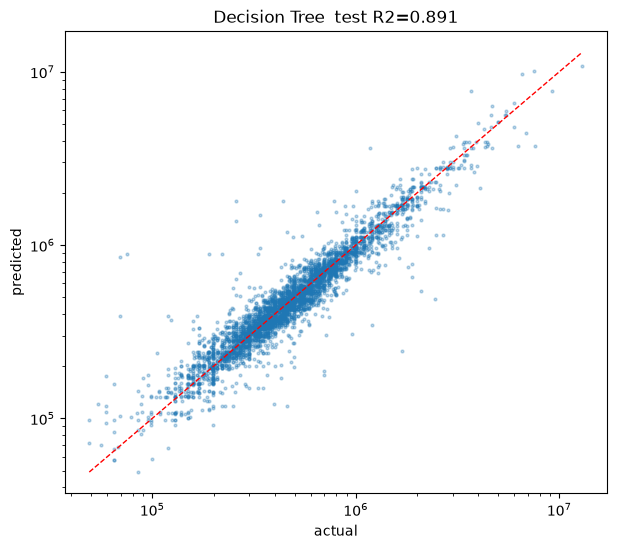

In [4]:
plot_test('Decision Tree', test, pred_te)

## 4. Feature importance
Built-in (impurity/gain) importance is biased toward high-cardinality features (`model` ~490 levels), so permutation importance on validation is shown next to it.

In [5]:
importance(best, X, val)

,built-in,permutation (val)
engine_capacity,0.315,0.358
car_age,0.363,0.274
model,0.120,0.155
brand,0.075,0.103
fuel_type,0.032,0.047
gear_type,0.050,0.039
mileage,0.040,0.021
color,0.005,0.002


## 5. Where is the error? (validation, price scale)

In [6]:
by_age, by_model = error_tables(best, X, val)
display(by_age)
by_model

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",245,201082.849,0.124
"(2, 5]",1264,110309.055,0.115
"(5, 8]",1352,74188.222,0.119
"(8, 12]",964,72327.350,0.142
"(12, 16]",461,50795.110,0.177
"(16, 20]",126,73427.030,0.284
"(20, 25]",60,73425.455,0.328


n         MAE   MAPE  med_price
brand         model                                       
PORSCHE       CAYENNE     27  439838.318  0.167  2990000.0
MERCEDES-BENZ E220        10  277553.020  0.265  1009500.0
              E300        19  248774.294  0.179  1259000.0
BMW           X3          12  230326.641  0.302   604000.0
TOYOTA        ALPHARD     57  198579.219  0.132  1780000.0
BMW           X5          13  198251.757  0.128  1860000.0
MINI          COOPER      16  191055.872  0.251   496500.0
TOYOTA        VELLFIRE    50  176179.079  0.141  1344000.0
HYUNDAI       STARIA      12  167662.079  0.128  1024500.0
MERCEDES-BENZ C220        15  164632.270  0.151  1150000.0
BMW           330E        23  152111.993  0.151   998000.0
              530E        35  143783.075  0.141   950000.0
MERCEDES-BENZ C350        16  137970.788  0.194   569500.0
BMW           320D        11  132561.041  0.125   619000.0
MINI          COUNTRYMAN  24  127141.671  0.148   794500.0